## Validation File

In [40]:
## Import required models

import re
import nltk
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,LancasterStemmer
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB,MultinomialNB
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from mlxtend.plotting import plot_confusion_matrix

In [41]:
## Loading the model
nb_model = joblib.load(r"D:\Innomatics\Git_Uploads\twitter_sentiment_analysis\Model\Twitter_Sentiemnt_Analysis_TfIdf.pkl")
tfidf = nb_model.tfidf

In [42]:
## Loading the validation data
df = pd.read_csv(r"D:\Innomatics\Git_Uploads\twitter_sentiment_analysis\data\twitter_validation.csv",header=None,
                 names=["tweet_id", "entity", "sentiment", "tweet"]
                 )
df.sample(5)

,tweet_id,entity,sentiment,tweet
405,6992,johnson&johnson,Positive,"By combining product #engagement #analytics, #..."
191,2430,Borderlands,Positive,Platinum is the best loot @Borderlands #PS4sha...
277,8179,Microsoft,Positive,Trust in Technology is Important !\n@satyanade...
495,8055,Microsoft,Positive,special shoutouts to microsoft excel 2013
559,9029,Nvidia,Negative,Anyone notice the ratio between conferred buy ...


In [43]:
df.shape

(1000, 4)

In [44]:
df.isnull().sum()

tweet_id     0
entity       0
sentiment    0
tweet        0
dtype: int64

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   1000 non-null   int64
 1   entity     1000 non-null   str  
 2   sentiment  1000 non-null   str  
 3   tweet      1000 non-null   str  
dtypes: int64(1), str(3)
memory usage: 182.1 KB


In [46]:
## Droping the Irrevelant sentiment tag as model is not trained for it
df = df[df["sentiment"] != "Irrelevant"].reset_index(drop=True)
df["sentiment"].value_counts()

sentiment
Neutral     285
Positive    277
Negative    266
Name: count, dtype: int64

In [47]:
df.dropna(subset="tweet",inplace=True)

In [48]:
df.drop(axis=0,columns=["tweet_id","entity"],inplace=True)

In [49]:
sentiment_num = {"Negative": 0, "Neutral": 1, "Positive": 2}
df["sentiment"] = df["sentiment"].map(sentiment_num)
df["sentiment"].value_counts()

sentiment
1    285
2    277
0    266
Name: count, dtype: int64

In [50]:
## Test preprocessing
sw= stopwords.words("english")

n_sw = ['don', "don't", 'couldn', 'aren', "aren't", "not", "couldn't",
        'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
        "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn',
        "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan',
        "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren',
        "weren't", 'won', "won't", 'wouldn', "wouldn't"]

p_sw = set(sw).difference(n_sw)
ps=PorterStemmer()

In [51]:
## Text Preprocessing Funsction
def text_preprocessing(tweet):
    ## Lower Case
    tweet = tweet.lower()
    ## Removing tags and links
    tweet = re.sub(r"http\S+|www\S+","",tweet) ## Removes Link
    tweet = re.sub(r"@\w+|@+","",tweet) ## Removes Mentions
    tweet = re.sub(r"<\S+","",tweet) ## Removes Tage
    tweet = re.sub(r"\w\S+\.com\S+","",tweet) ## removes other .com text
    tweet = re.sub(r"\w+\.\S+","",tweet)  ## removes site links
    tweet =  re.sub(r"#","",tweet) ## Removes symbol
    ## Remove punctuations
    spec_char = r"[^a-z!?\s]"
    tweet = re.sub(spec_char,"",tweet)
    ## Tokenization
    tweet = tweet.split()
    ## Steming and Pos Stopwords removal
    tweet = [ps.stem(word) for word in tweet if word not in p_sw]
    tweet = " ".join(tweet)
    
    return tweet

In [52]:
df["tweet"] = df["tweet"].apply(text_preprocessing)
df.head(5)

,sentiment,tweet
0,1,bbc news amazon boss jeff bezo reject claim co...
1,0,pay word function poorli chromebook?
2,0,csgo matchmak full closet hack truli aw game
3,1,presid slap american face realli commit unlaw ...
4,0,hi ive madelein mccann cellar past year littl ...


## Vectorization

In [54]:
X = tfidf.transform(df["tweet"])
y = df["sentiment"]
X.shape,y.shape

((828, 20000), (828,))

## Prediction

In [55]:
y_pred = nb_model.predict(X)

## Evaluation

In [60]:
acc = accuracy_score(y,y_pred)
print("Validation accuracy score :",round(acc,2))

Validation accuracy score : 0.86


In [62]:
print(classification_report(y,y_pred,target_names= ["Negative","Neutral","Positive"]))

              precision    recall  f1-score   support

    Negative       0.81      0.90      0.85       266
     Neutral       0.91      0.76      0.83       285
    Positive       0.86      0.91      0.88       277

    accuracy                           0.86       828
   macro avg       0.86      0.86      0.86       828
weighted avg       0.86      0.86      0.86       828



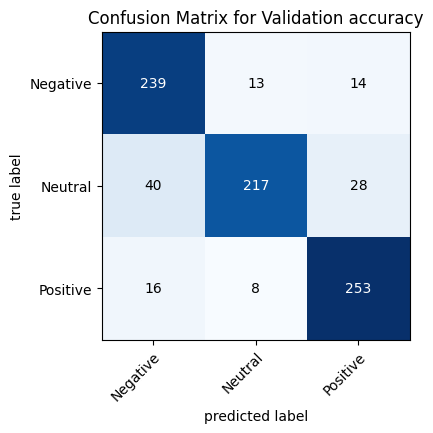

In [65]:
cm = confusion_matrix(y,y_pred)
fig,ax = plot_confusion_matrix(cm,class_names=["Negative","Neutral","Positive"],figsize=(4,4))
plt.title("Confusion Matrix for Validation accuracy")
plt.show()

## Comparsion

In [67]:
results = pd.DataFrame({
    "Dataset" : ["Train","Test","Validate"],
    "Accuracy" : [0.83,0.79,0.86]
})

results

,Dataset,Accuracy
0,Train,0.83
1,Test,0.79
2,Validate,0.86
